In [1]:
# --- Setup: Setty Lab plot aesthetics (setty.plots) ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.cmap"] = "Spectral_r"
for side in ("top", "right", "bottom", "left"):
    plt.rcParams[f"axes.spines.{side}"] = True   # line/bar panels keep bottom+left; despined per-plot
plt.rcParams["axes.grid"] = False
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["font.size"] = 12

PROJECT = Path(".")
FLOW = PROJECT / "data"
FIG  = Path("figures") / "growth_viability"
FIG.mkdir(parents=True, exist_ok=True)

# Consistent drug colors across every panel (control = neutral grey)
DRUG_COLORS = {"DMSO": "#4d4d4d", "EED": "#1f78b4", "TAZ": "#e31a1c", "UTX": "#bdbdbd"}
FOCUS  = ["DMSO", "EED", "TAZ"]          # the three the analysis is about
CONTEXT = ["UTX"]                         # shown faint where present
from matplotlib.font_manager import findfont, FontProperties
print("matplotlib resolves sans-serif to:",
      Path(findfont(FontProperties(family=plt.rcParams["font.sans-serif"]))).name)


matplotlib resolves sans-serif to: LiberationSans-Regular.ttf


## 1. Growth curves (dilution-corrected cell counts)

In [2]:
# --- Parse the dilution-corrected block from the counts sheet ---
xlsx = FLOW / "250214_K27me123ac_P2S25p_TAZEEDUTX_cell_counts.xlsx"
raw = pd.read_excel(xlsx, sheet_name="counts", header=None)

TIMES    = [4, 8, 24, 48, 79, 96, 171]
TOT_COLS = [3, 5, 7, 9, 11, 13, 15]     # "{t}hr total"  columns
VIA_COLS = [4, 6, 8, 10, 12, 14, 16]    # "{t}hr viable" columns

# seed density (0 h) from the raw-block label like ".410M"
seed = float(str(raw.iloc[1, 0]).replace("M", "").strip())

# locate the "Dilution corrected" block and take its 8 condition/rep rows
dc0 = int(raw.index[raw[0].astype(str).str.strip() == "Dilution corrected"][0])
block = raw.iloc[dc0:dc0 + 8]

recs = []
for _, r in block.iterrows():
    cond, rep = r[1], r[2]
    recs.append(dict(cond=cond, rep=rep, time=0, total=seed, viable=seed))  # t=0 anchor
    for t, tc, vc in zip(TIMES, TOT_COLS, VIA_COLS):
        recs.append(dict(cond=cond, rep=rep, time=t,
                         total=float(r[tc]), viable=float(r[vc])))
counts = pd.DataFrame(recs)
counts["viability"] = 100 * counts["viable"] / counts["total"]
print(f"seed (0 h) = {seed} x10^6;  conditions = {sorted(counts['cond'].unique())}")
counts.head(8)


seed (0 h) = 0.41 x10^6;  conditions = ['DMSO', 'EED', 'TAZ', 'UTX']


,cond,rep,time,total,viable,viability
0,DMSO,a,0,0.410,0.410,100.000000
1,DMSO,a,4,0.484,0.478,98.760331
2,DMSO,a,8,0.596,0.588,98.657718
3,DMSO,a,24,0.854,0.846,99.063232
4,DMSO,a,48,1.492,1.476,98.927614
5,DMSO,a,79,2.404,2.328,96.838602
6,DMSO,a,96,4.144,4.008,96.718147
7,DMSO,a,171,14.304,12.416,86.800895


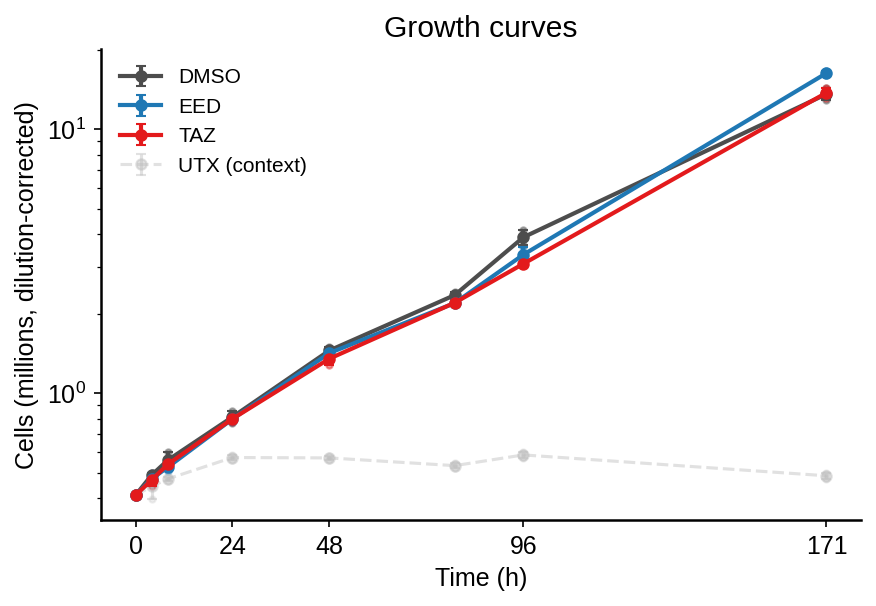

time,0,4,8,24,48,79,96,171
cond,,,,,,,,
DMSO,0.41,0.49,0.56,0.81,1.45,2.35,3.89,13.57
EED,0.41,0.47,0.52,0.80,1.42,2.19,3.34,16.29
TAZ,0.41,0.47,0.54,0.80,1.35,2.20,3.09,13.73


In [3]:
# --- Growth curve: dilution-corrected TOTAL cells vs time (mean of 2 reps +/- half-range) ---
def summarise(df, value):
    g = df.groupby(["cond", "time"])[value]
    out = g.agg(["mean", "min", "max"]).reset_index()
    out["lo"] = out["mean"] - out["min"]
    out["hi"] = out["max"] - out["mean"]
    return out

growth = summarise(counts, "total")

fig, ax = plt.subplots(figsize=(6, 4.2))
for cond in FOCUS + CONTEXT:
    d = growth[growth["cond"] == cond].sort_values("time")
    faint = cond in CONTEXT
    ax.errorbar(d["time"], d["mean"], yerr=[d["lo"], d["hi"]],
                marker="o", ms=5, lw=2 if not faint else 1.5,
                ls="-" if not faint else "--",
                color=DRUG_COLORS[cond], capsize=2.5,
                alpha=0.45 if faint else 1.0,
                label=cond + (" (context)" if faint else ""), zorder=2 if faint else 3)
    # individual replicates, faint
    rd = counts[counts["cond"] == cond]
    ax.scatter(rd["time"], rd["total"], s=9, color=DRUG_COLORS[cond],
               alpha=0.25 if faint else 0.45, zorder=1)

ax.set_yscale("log")
ax.set_xlabel("Time (h)")
ax.set_ylabel("Cells (millions, dilution-corrected)")
ax.set_title("Growth curves")
ax.set_xticks([0, 24, 48, 96, 171])
ax.legend(frameon=False, fontsize=10, loc="upper left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "growth_curves.pdf", bbox_inches="tight")
plt.show()

# quick table
growth[growth["cond"].isin(FOCUS)].pivot_table(index="cond", columns="time", values="mean").round(2)


## 2. Viability over time

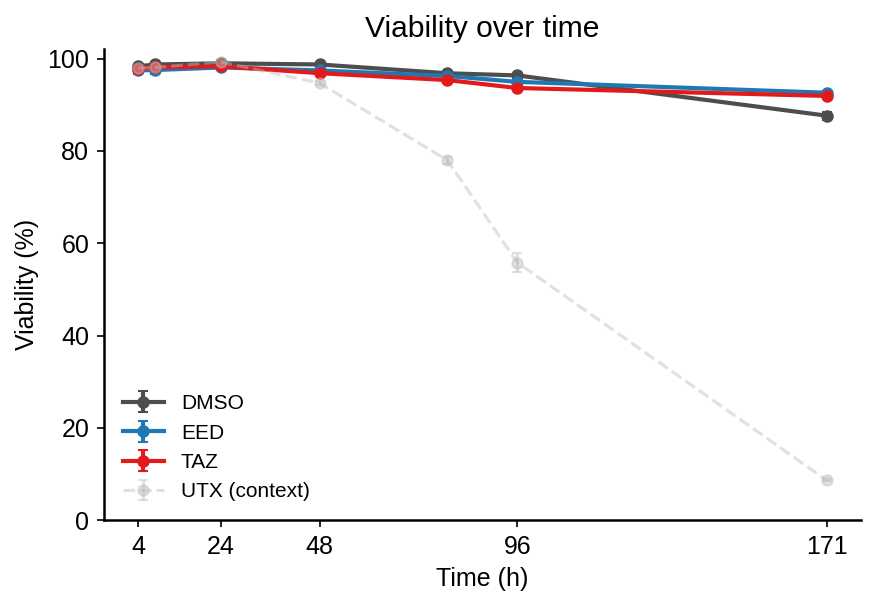

time,4,8,24,48,79,96,171
cond,,,,,,,
DMSO,98.4,98.7,99.0,98.8,96.9,96.4,87.7
EED,97.5,97.5,98.1,97.5,96.3,95.0,92.6
TAZ,97.8,98.1,98.4,96.9,95.4,93.7,91.9


In [4]:
# --- Viability (%) vs time ---
viab = summarise(counts[counts["time"] > 0], "viability")

fig, ax = plt.subplots(figsize=(6, 4.2))
for cond in FOCUS + CONTEXT:
    d = viab[viab["cond"] == cond].sort_values("time")
    faint = cond in CONTEXT
    ax.errorbar(d["time"], d["mean"], yerr=[d["lo"], d["hi"]],
                marker="o", ms=5, lw=2 if not faint else 1.5,
                ls="-" if not faint else "--",
                color=DRUG_COLORS[cond], capsize=2.5,
                alpha=0.45 if faint else 1.0,
                label=cond + (" (context)" if faint else ""))

ax.set_xlabel("Time (h)")
ax.set_ylabel("Viability (%)")
ax.set_title("Viability over time")
ax.set_ylim(0, 102)
ax.set_xticks([4, 24, 48, 96, 171])
ax.legend(frameon=False, fontsize=10, loc="lower left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "viability_curves.pdf", bbox_inches="tight")
plt.show()

viab[viab["cond"].isin(FOCUS)].pivot_table(index="cond", columns="time", values="mean").round(1)


## 3. Cell-cycle curves at 8 h

In [5]:
# --- Load DNA content from the 30 flow CSVs and mode-scale (verbatim from source notebook) ---
DATA_DIR = FLOW / "20260206_drug_8only_aurora"

def _hist_mode(x, bins="fd"):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if x.size == 0: return np.nan
    if np.all(x == x[0]): return float(x[0])
    counts_, edges = np.histogram(x, bins=bins)
    if counts_.sum() == 0: return np.nan
    i = int(np.argmax(counts_))
    return float((edges[i] + edges[i + 1]) / 2.0)

frames = []
for fp in sorted(DATA_DIR.glob("*.csv")):
    d = pd.read_csv(fp, usecols=["DRAQ5-A"])   # DNA content only -> fast, faithful to the scaling
    d["sample_id"] = fp.stem
    frames.append(d)
flow = pd.concat(frames, ignore_index=True)
parts = flow["sample_id"].str.split("_", expand=True)
flow["mark"], flow["drug"], flow["time"] = parts[1].str.split().str[-1], parts[2], parts[3].astype(int)

modes = (flow.groupby("sample_id", sort=False)["DRAQ5-A"]
             .apply(lambda s: _hist_mode(s.to_numpy())).rename("mode").reset_index())
REF = float(np.nanmedian(modes["mode"]))
flow["DNA-A_scaled"] = flow["DRAQ5-A"] * flow["sample_id"].map(dict(zip(modes["sample_id"], REF / modes["mode"])))
print(f"{len(flow):,} events | ref_mode (G1/2N) = {REF:.1f} | 2x (G2M/4N) = {2*REF:.1f}")
print("drugs:", sorted(flow['drug'].unique()), "| times:", sorted(flow['time'].unique()),
      "| marks:", sorted(flow['mark'].unique()))


157,729 events | ref_mode (G1/2N) = 322.5 | 2x (G2M/4N) = 644.9
drugs: ['DMSO', 'EED', 'TAZ'] | times: [8] | marks: ['ac', 'me1', 'me2', 'me3', 'p2']


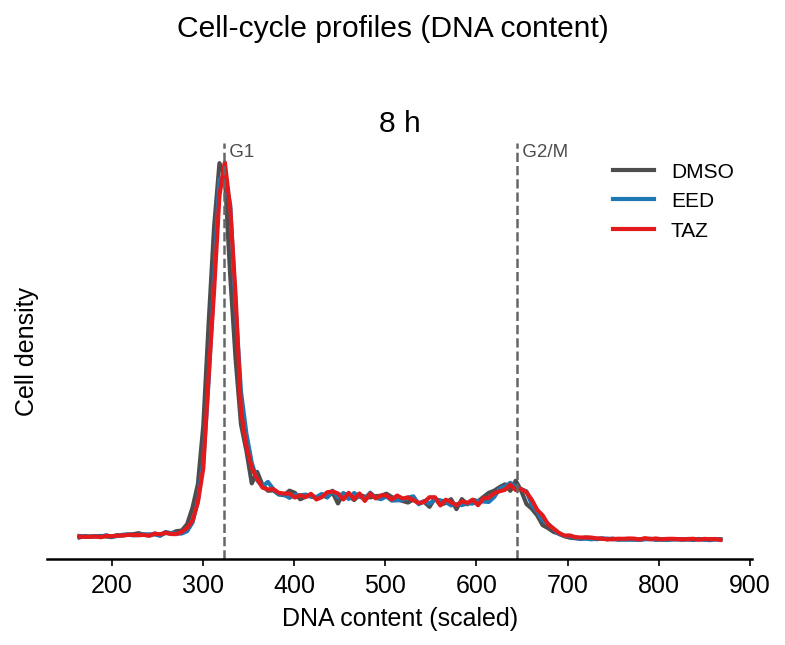

In [6]:
# --- 3a. DNA-content cell-cycle profile curves (pooled marks), 8 h ---
lo, hi = 0.5 * REF, 2.7 * REF
edges = np.linspace(lo, hi, 121)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, axes = plt.subplots(1, 1, figsize=(5.4, 4.2)); axes = np.atleast_1d(axes)
for ax, t in zip(np.atleast_1d(axes), [8]):
    for cond in FOCUS:
        x = flow[(flow["drug"] == cond) & (flow["time"] == t)]["DNA-A_scaled"].to_numpy()
        x = x[(x > lo) & (x < hi)]
        dens, _ = np.histogram(x, bins=edges, density=True)
        ax.plot(centers, dens, lw=2, color=DRUG_COLORS[cond], label=cond)
    ax.axvline(REF, ls="--", lw=1.2, color="0.4"); ax.axvline(2 * REF, ls="--", lw=1.2, color="0.4")
    ax.text(REF, ax.get_ylim()[1], " G1", va="top", ha="left", fontsize=9, color="0.3")
    ax.text(2 * REF, ax.get_ylim()[1], " G2/M", va="top", ha="left", fontsize=9, color="0.3")
    ax.set_title(f"{t} h")
    ax.set_xlabel("DNA content (scaled)")
    ax.set_yticks([])
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("Cell density")
axes[0].legend(frameon=False, fontsize=10, loc="upper right")
fig.suptitle("Cell-cycle profiles (DNA content)", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "cellcycle_profiles.pdf", bbox_inches="tight")
plt.show()


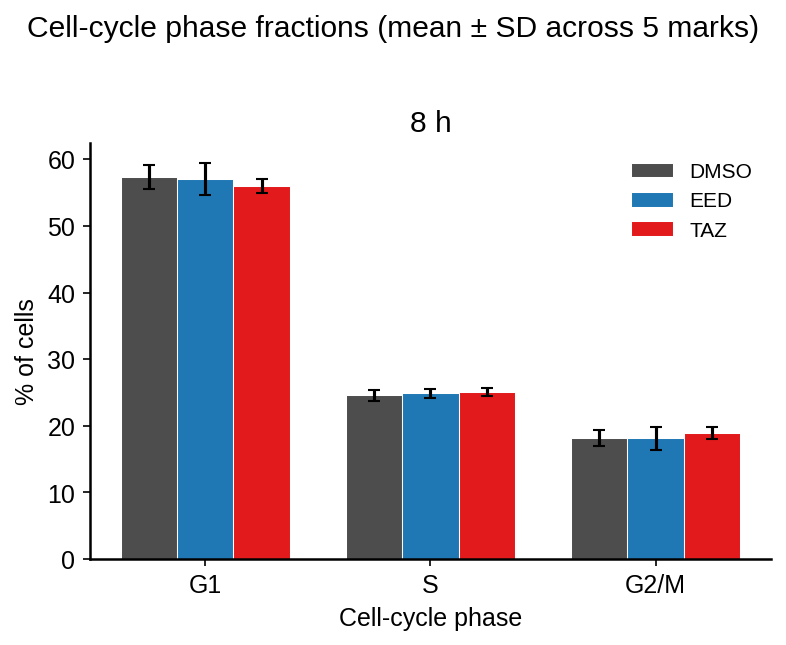

,phase,G1,S,G2/M
drug,time,,,
DMSO,8,57.3,24.6,18.2
EED,8,57.0,24.9,18.1
TAZ,8,56.0,25.1,18.9


In [7]:
# --- 3b. Phase fractions from univariate DNA gates; error bars = SD across the 5 marks ---
PHASE_ORDER = ["G1", "S", "G2/M"]
def assign_phase(x):
    return np.where(x < 1.25 * REF, "G1", np.where(x < 1.75 * REF, "S", "G2/M"))

f = flow[(flow["DNA-A_scaled"] > 0.6 * REF) & (flow["DNA-A_scaled"] < 2.6 * REF)].copy()
f["phase"] = assign_phase(f["DNA-A_scaled"].to_numpy())

cnt = f.groupby(["drug", "time", "mark", "phase"]).size().rename("n").reset_index()
cnt["frac"] = 100 * cnt["n"] / cnt.groupby(["drug", "time", "mark"])["n"].transform("sum")
mean = cnt.pivot_table(index=["drug", "time"], columns="phase", values="frac", aggfunc="mean")
sd   = cnt.pivot_table(index=["drug", "time"], columns="phase", values="frac", aggfunc="std")

fig, axes = plt.subplots(1, 1, figsize=(5.4, 4.2)); axes = np.atleast_1d(axes)
w = 0.25
for ax, t in zip(np.atleast_1d(axes), [8]):
    xpos = np.arange(len(PHASE_ORDER))
    for i, cond in enumerate(FOCUS):
        m = [mean.loc[(cond, t), p] for p in PHASE_ORDER]
        e = [sd.loc[(cond, t), p]   for p in PHASE_ORDER]
        ax.bar(xpos + (i - 1) * w, m, w, yerr=e, capsize=3,
               color=DRUG_COLORS[cond], label=cond, edgecolor="white", linewidth=0.5)
    ax.set_xticks(xpos); ax.set_xticklabels(PHASE_ORDER)
    ax.set_title(f"{t} h")
    ax.set_xlabel("Cell-cycle phase")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("% of cells")
axes[0].legend(frameon=False, fontsize=10)
fig.suptitle("Cell-cycle phase fractions (mean ± SD across 5 marks)", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "cellcycle_phase_fractions.pdf", bbox_inches="tight")
plt.show()

GATED = mean.reindex(columns=PHASE_ORDER)   # keep gated fractions for the section-4 comparison
(GATED.round(1))


## 4. Watson v. DJF

In [8]:
# --- Watson / Dean-Jett-Fox model implementation ---
from scipy.optimize import least_squares
from scipy.integrate import trapezoid

def _gauss(x, mu, s):
    return np.exp(-0.5 * ((x - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))

def _s_phase(x, mu1, mu2, sig, poly=(1.0, 0.0, 0.0)):
    """Broadened intermediate (S) distribution: poly weight over (mu1, mu2)
    convolved with a Gaussian of width `sig`. poly=(1,0,0) -> Watson uniform;
    a full quadratic -> Dean-Jett-Fox. Returned area-normalised (unit area)."""
    ts = np.linspace(mu1, mu2, 100)
    u = (ts - mu1) / (mu2 - mu1)
    w = np.clip(poly[0] + poly[1] * u + poly[2] * u * u, 0, None)
    dt = ts[1] - ts[0]
    S = np.zeros_like(x, dtype=float)
    for t, ww in zip(ts, w):
        S += ww * _gauss(x, t, sig) * dt
    area = trapezoid(S, x)
    return S / area if area > 0 else S

def dna_model(p, x, model="watson"):
    mu1, mu2, s1, s2, aG1, aS, aG2 = p[:7]
    poly = (1.0, 0.0, 0.0) if model == "watson" else (1.0, p[7], p[8])
    return (aG1 * _gauss(x, mu1, s1)
            + aG2 * _gauss(x, mu2, s2)
            + aS  * _s_phase(x, mu1, mu2, s1, poly))

def fit_dna(counts, centers, model="watson"):
    """Least-squares fit; returns (params, phase% dict). Amplitudes are the
    component areas, so phase fractions = area / total area."""
    at = trapezoid(counts, centers)
    #   [ mu1,     mu2,      s1,       s2,       aG1,    aS,     aG2  ]
    p0 = [REF,     2.28*REF, 0.08*REF, 0.11*REF, .5*at,  .2*at,  .3*at]
    lb = [.9*REF,  1.80*REF, .03*REF,  .05*REF,  0,      0,      0]
    ub = [1.1*REF, 2.60*REF, .15*REF,  .22*REF,  2*at,   2*at,   2*at]
    if model == "djf":
        p0 += [0.0, 0.0]; lb += [-2.9, -2.9]; ub += [2.9, 2.9]
    r = least_squares(lambda p: dna_model(p, centers, model) - counts,
                      p0, bounds=(lb, ub), max_nfev=8000)
    aG1, aS, aG2 = r.x[4:7]; tot = aG1 + aS + aG2
    return r.x, {"G1": 100*aG1/tot, "S": 100*aS/tot, "G2/M": 100*aG2/tot}

# histogram grid for fitting (2N .. ~4N+)
FLO, FHI = 0.55 * REF, 2.75 * REF
FEDGES = np.linspace(FLO, FHI, 111)
FCTR = 0.5 * (FEDGES[:-1] + FEDGES[1:])
print(f"fit grid {FLO:.0f}–{FHI:.0f} (REF={REF:.0f}); G2/M allowed to float 1.80–2.60×μ1")


fit grid 177–887 (REF=322); G2/M allowed to float 1.80–2.60×μ1


In [9]:
# --- Fit every mark (n=5) for both models; collect phase fractions ---
def _hist(drug, t, mark=None):
    q = (flow["drug"] == drug) & (flow["time"] == t)
    if mark is not None:
        q &= flow["mark"] == mark
    x = flow.loc[q, "DNA-A_scaled"].to_numpy()
    x = x[(x > FLO) & (x < FHI)]
    c, _ = np.histogram(x, bins=FEDGES)
    return c.astype(float)

rows = []
for model in ["watson", "djf"]:
    for cond in FOCUS:
        for t in [8]:
            for mk in sorted(flow["mark"].unique()):
                _, fr = fit_dna(_hist(cond, t, mk), FCTR, model)
                rows.append(dict(model=model, drug=cond, time=t, mark=mk, **fr))
fitdf = pd.DataFrame(rows)

fit_mean = fitdf.groupby(["model", "drug", "time"])[PHASE_ORDER].mean()
fit_sd   = fitdf.groupby(["model", "drug", "time"])[PHASE_ORDER].std()
print("Watson phase % (mean across 5 marks):")
print(fit_mean.loc["watson"].round(1).to_string())
print("\nDean-Jett-Fox phase % (mean across 5 marks):")
print(fit_mean.loc["djf"].round(1).to_string())


Watson phase % (mean across 5 marks):
             G1     S  G2/M
drug time                  
DMSO 8     41.0  55.0   4.0
EED  8     41.5  54.9   3.5
TAZ  8     40.9  55.3   3.8

Dean-Jett-Fox phase % (mean across 5 marks):
             G1     S  G2/M
drug time                  
DMSO 8     39.3  54.9   5.8
EED  8     40.3  53.2   6.5
TAZ  8     40.0  53.7   6.2


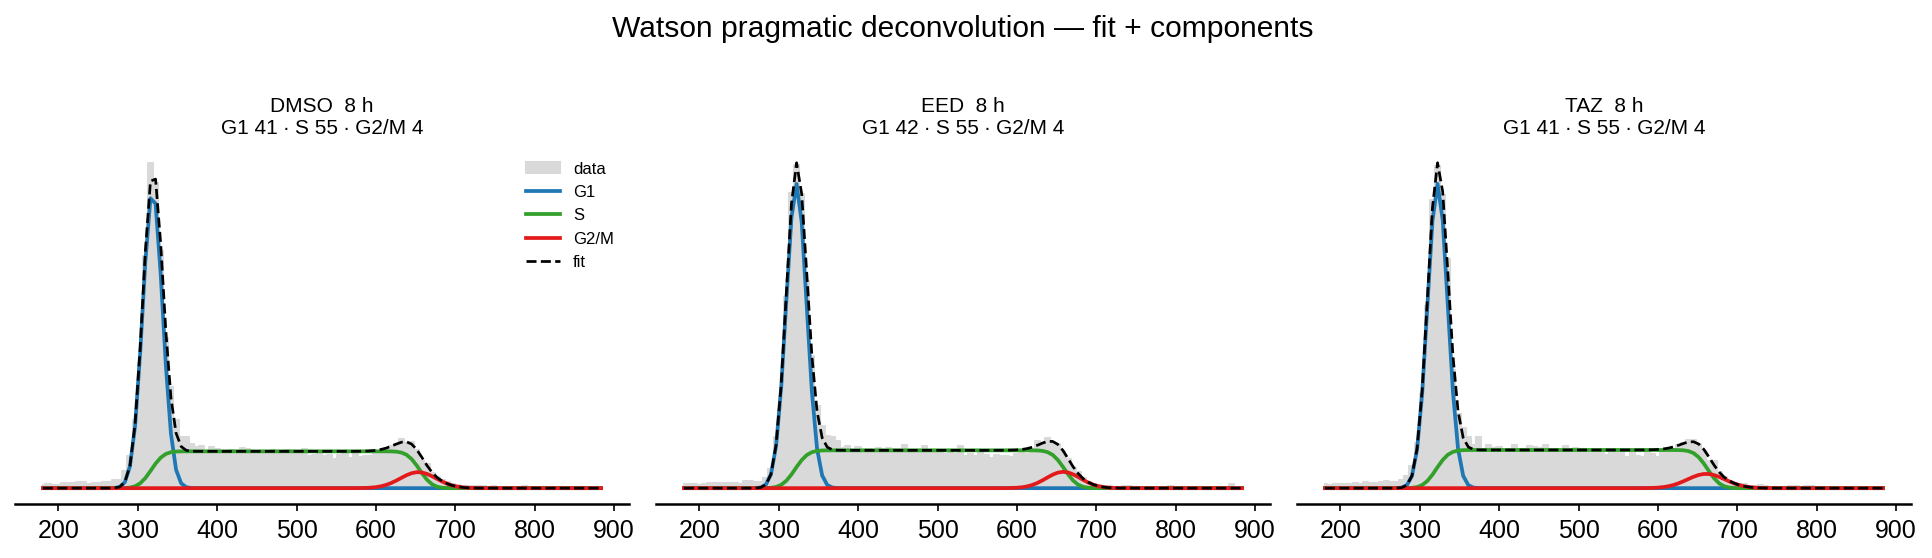

In [10]:
# --- Overlay: Watson fit + G1/S/G2M components on the pooled DNA histogram ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7), sharex=True, squeeze=False)
for r_i, t in enumerate([8]):
    for c_i, cond in enumerate(FOCUS):
        ax = axes[r_i, c_i]
        counts = _hist(cond, t)
        par, fr = fit_dna(counts, FCTR, "watson")
        mu1, mu2, s1, s2, aG1, aS, aG2 = par
        ax.fill_between(FCTR, counts, color="0.85", step="mid", label="data")
        ax.plot(FCTR, aG1 * _gauss(FCTR, mu1, s1), color="#1f78b4", lw=1.8, label="G1")
        ax.plot(FCTR, aS * _s_phase(FCTR, mu1, mu2, s1), color="#33a02c", lw=1.8, label="S")
        ax.plot(FCTR, aG2 * _gauss(FCTR, mu2, s2), color="#e31a1c", lw=1.8, label="G2/M")
        ax.plot(FCTR, dna_model(par, FCTR, "watson"), "k--", lw=1.3, label="fit")
        ax.set_title(f"{cond}  {t} h\nG1 {fr['G1']:.0f} · S {fr['S']:.0f} · G2/M {fr['G2/M']:.0f}",
                     fontsize=10)
        ax.set_yticks([])
        for s in ("top", "right", "left"):
            ax.spines[s].set_visible(False)
        if r_i == 1:
            ax.set_xlabel("DNA content (scaled)")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper right")
fig.suptitle("Watson pragmatic deconvolution — fit + components", y=1.0)
fig.tight_layout()
fig.savefig(FIG / "cellcycle_watson_fits.pdf", bbox_inches="tight")
plt.show()


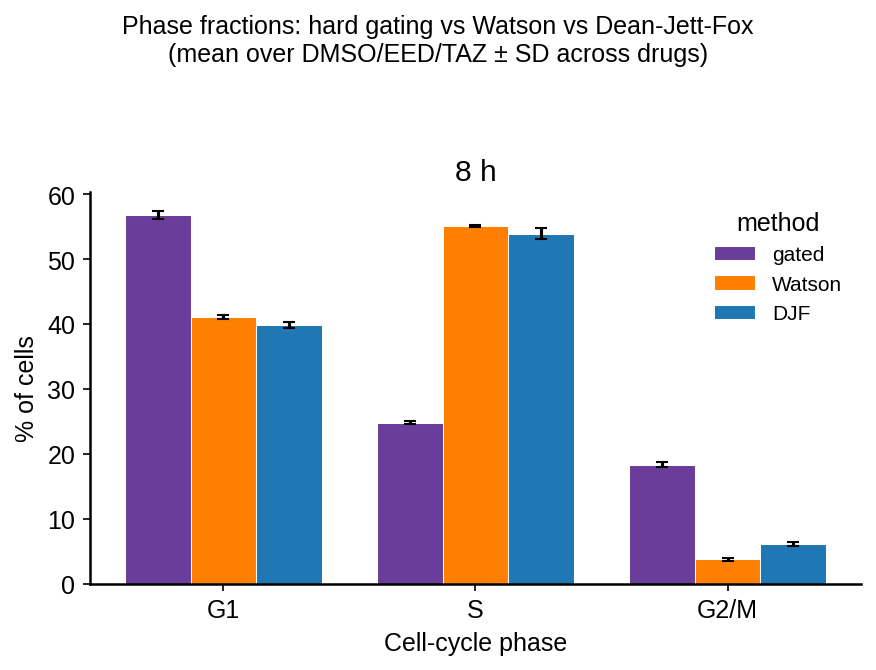

gated             Watson              DJF           
phase    G1     S  G2/M     G1     S G2/M    G1     S G2/M
time                                                      
8      56.8  24.8  18.4   41.1  55.1  3.8  39.9  53.9  6.2

In [11]:
# --- Compare methods: hard gating vs Watson vs DJF (avg over DMSO/EED/TAZ; drugs ~identical) ---
comp = {"gated": GATED.groupby("time").mean(),
        "Watson": fit_mean.loc["watson"].groupby("time").mean(),
        "DJF": fit_mean.loc["djf"].groupby("time").mean()}
comp_sd = {"gated": GATED.groupby("time").std(),
           "Watson": fit_mean.loc["watson"].groupby("time").std(),
           "DJF": fit_mean.loc["djf"].groupby("time").std()}
METHODS = ["gated", "Watson", "DJF"]
MCOL = {"gated": "#6a3d9a", "Watson": "#ff7f00", "DJF": "#1f78b4"}

fig, axes = plt.subplots(1, 1, figsize=(6.0, 4.2)); axes = np.atleast_1d(axes)
w = 0.26
for ax, t in zip(axes, [8]):
    xpos = np.arange(len(PHASE_ORDER))
    for i, meth in enumerate(METHODS):
        vals = [comp[meth].loc[t, p] for p in PHASE_ORDER]
        err  = [comp_sd[meth].loc[t, p] for p in PHASE_ORDER]
        ax.bar(xpos + (i - 1) * w, vals, w, yerr=err, capsize=3,
               color=MCOL[meth], label=meth, edgecolor="white", linewidth=0.5)
    ax.set_xticks(xpos); ax.set_xticklabels(PHASE_ORDER)
    ax.set_title(f"{t} h"); ax.set_xlabel("Cell-cycle phase")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("% of cells")
axes[0].legend(frameon=False, fontsize=10, title="method")
fig.suptitle("Phase fractions: hard gating vs Watson vs Dean-Jett-Fox\n(mean over DMSO/EED/TAZ ± SD across drugs)",
             y=1.06, fontsize=12)
fig.tight_layout()
fig.savefig(FIG / "cellcycle_method_comparison.pdf", bbox_inches="tight")
plt.show()

# side-by-side table
tbl = pd.concat({m: comp[m].round(1) for m in METHODS}, axis=1)
tbl


In [12]:
# --- Watson per-mark fractions: pairwise between-drug effect sizes + MTC ---
from scipy import stats

wat = fitdf[fitdf["model"] == "watson"].copy()   # drug,time,mark,G1,S,G2/M  (n=5 marks each)
wat_mean = wat.groupby(["drug", "time"])[PHASE_ORDER].mean()
wat_sd   = wat.groupby(["drug", "time"])[PHASE_ORDER].std()

PAIRS = [("DMSO", "EED"), ("DMSO", "TAZ"), ("EED", "TAZ")]
rows = []
for t in [8]:
    for ph in PHASE_ORDER:
        for a, b in PAIRS:
            sa = wat[(wat.time == t) & (wat.drug == a)].set_index("mark")[ph]
            sb = wat[(wat.time == t) & (wat.drug == b)].set_index("mark")[ph]
            marks = sorted(set(sa.index) & set(sb.index))            # pair by mark
            da, db = sa.loc[marks].to_numpy(), sb.loc[marks].to_numpy()
            d = da - db; n = len(d)
            mdiff = d.mean(); se = d.std(ddof=1) / np.sqrt(n)
            tcrit = stats.t.ppf(0.975, n - 1)
            _, p = stats.ttest_rel(da, db)
            rows.append(dict(time=f"{t}h", phase=ph, pair=f"{a}-{b}", mean_diff=mdiff,
                             ci_lo=mdiff - tcrit * se, ci_hi=mdiff + tcrit * se, p_raw=p))
mtc = pd.DataFrame(rows)

# multiple-testing correction across all 9 pairwise comparisons (8 h only)
p = mtc["p_raw"].to_numpy(); m = len(p)
mtc["p_bonferroni"] = np.minimum(p * m, 1.0)
order = np.argsort(p); ranks = np.empty(m, int); ranks[order] = np.arange(1, m + 1)
q = p * m / ranks; qs = q[order]; qmono = np.minimum.accumulate(qs[::-1])[::-1]
qBH = np.empty(m); qBH[order] = np.minimum(qmono, 1.0)
mtc["q_BH"] = qBH

disp = mtc.copy()
disp["Δ (pp)"] = disp["mean_diff"].round(1)
disp["95% CI"] = ("[" + disp["ci_lo"].round(1).astype(str) + ", "
                  + disp["ci_hi"].round(1).astype(str) + "]")
for c in ["p_raw", "q_BH", "p_bonferroni"]:
    disp[c] = disp[c].round(3)
disp = disp[["time", "phase", "pair", "Δ (pp)", "95% CI", "p_raw", "q_BH", "p_bonferroni"]]
print(f"Pairwise between-drug comparison of Watson fractions (paired by mark, n=5); {m} tests.")
print("NOTE: marks are pseudo-replicates of one culture -> p/q are DESCRIPTIVE consistency only.\n")
print(disp.to_string(index=False))
print(f"\nq_BH < 0.05: {(mtc.q_BH < 0.05).sum()}/{m} | Bonferroni p < 0.05: {(mtc.p_bonferroni < 0.05).sum()}/{m}")
_i = mtc.mean_diff.abs().idxmax()
print(f"Largest |Δ|: {mtc.loc[_i,'mean_diff']:+.1f} pp  ({mtc.loc[_i,'time']} {mtc.loc[_i,'phase']} {mtc.loc[_i,'pair']})")
# BH-significant rows, if any
_sig = mtc[mtc.q_BH < 0.05]
print("BH-significant comparisons (descriptive):",
      "none" if _sig.empty else ", ".join(f"{r.time} {r.phase} {r.pair} (Δ{r.mean_diff:+.1f})" for r in _sig.itertuples()))


Pairwise between-drug comparison of Watson fractions (paired by mark, n=5); 9 tests.
NOTE: marks are pseudo-replicates of one culture -> p/q are DESCRIPTIVE consistency only.

time phase     pair  Δ (pp)      95% CI  p_raw  q_BH  p_bonferroni
  8h    G1 DMSO-EED    -0.6 [-2.6, 1.5]  0.497 0.940         1.000
  8h    G1 DMSO-TAZ     0.0 [-1.5, 1.5]  0.940 0.940         1.000
  8h    G1  EED-TAZ     0.6 [-1.2, 2.4]  0.412 0.940         1.000
  8h     S DMSO-EED     0.1 [-1.7, 1.8]  0.894 0.940         1.000
  8h     S DMSO-TAZ    -0.2 [-1.0, 0.6]  0.476 0.940         1.000
  8h     S  EED-TAZ    -0.3 [-2.1, 1.5]  0.648 0.940         1.000
  8h  G2/M DMSO-EED     0.5 [-0.1, 1.0]  0.085 0.766         0.766
  8h  G2/M DMSO-TAZ     0.2 [-1.8, 2.2]  0.809 0.940         1.000
  8h  G2/M  EED-TAZ    -0.3 [-2.1, 1.5]  0.690 0.940         1.000

q_BH < 0.05: 0/9 | Bonferroni p < 0.05: 0/9
Largest |Δ|: +0.6 pp  (8h G1 EED-TAZ)
BH-significant comparisons (descriptive): none


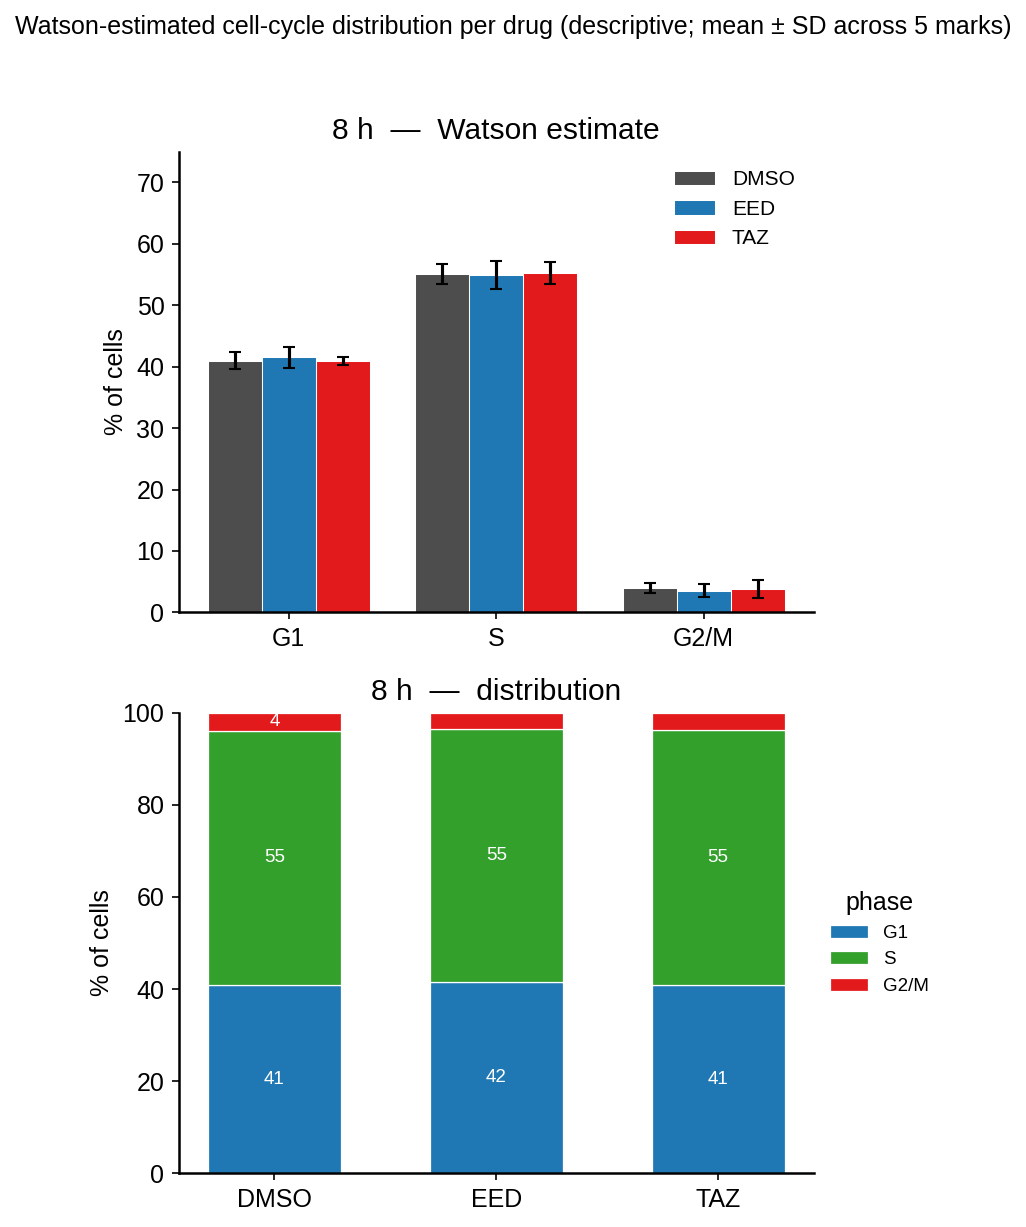

In [13]:
# --- Figure A: descriptive distribution (grouped bars + stacked), no significance stars ---
fig, axes = plt.subplots(2, 1, figsize=(6.0, 8), squeeze=False)
wgap = 0.26
for ax, t in zip(axes[0], [8]):
    xpos = np.arange(len(PHASE_ORDER))
    for i, d in enumerate(FOCUS):
        vals = [wat_mean.loc[(d, t), ph] for ph in PHASE_ORDER]
        err  = [wat_sd.loc[(d, t), ph]   for ph in PHASE_ORDER]
        ax.bar(xpos + (i - 1) * wgap, vals, wgap, yerr=err, capsize=3,
               color=DRUG_COLORS[d], label=d, edgecolor="white", linewidth=0.5)
    ax.set_xticks(xpos); ax.set_xticklabels(PHASE_ORDER)
    ax.set_title(f"{t} h  —  Watson estimate"); ax.set_ylim(0, 75)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
axes[0, 0].set_ylabel("% of cells"); axes[0, 0].legend(frameon=False, fontsize=10)
for ax, t in zip(axes[1], [8]):
    xpos = np.arange(len(FOCUS)); bottom = np.zeros(len(FOCUS))
    pcol = {"G1": "#1f78b4", "S": "#33a02c", "G2/M": "#e31a1c"}
    for ph in PHASE_ORDER:
        vals = [wat_mean.loc[(d, t), ph] for d in FOCUS]
        ax.bar(xpos, vals, 0.6, bottom=bottom, color=pcol[ph], label=ph, edgecolor="white", linewidth=0.6)
        for x, v, b in zip(xpos, vals, bottom):
            if v > 4:
                ax.text(x, b + v / 2, f"{v:.0f}", ha="center", va="center", fontsize=9, color="white")
        bottom += vals
    ax.set_xticks(xpos); ax.set_xticklabels(FOCUS); ax.set_title(f"{t} h  —  distribution"); ax.set_ylim(0, 100)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
axes[1, 0].set_ylabel("% of cells")
axes[1, 0].legend(frameon=False, fontsize=9, title="phase", loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.suptitle("Watson-estimated cell-cycle distribution per drug (descriptive; mean ± SD across 5 marks)", y=1.02, fontsize=12)
fig.tight_layout(); fig.savefig(FIG / "cellcycle_watson_between_drug.pdf", bbox_inches="tight"); plt.show()


## 5. Watson stats

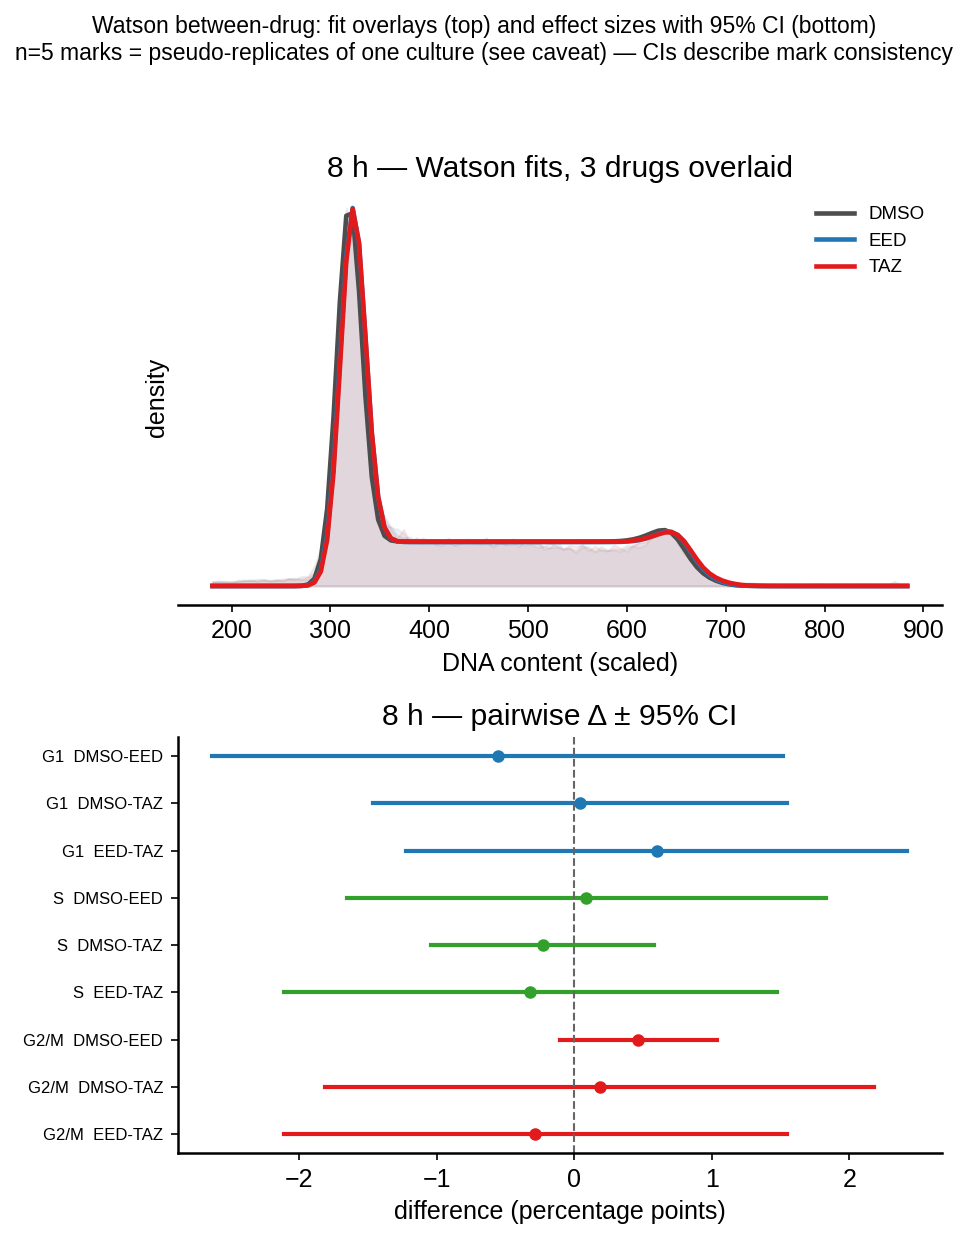

In [14]:
# --- Figure B (rebuttal): fit overlays (3 drugs) + pairwise effect sizes with 95% CI ---
fig, axes = plt.subplots(2, 1, figsize=(6.5, 8), squeeze=False)
# row 0: three drugs' Watson fits overlaid (normalized), faint data density behind
for ax, t in zip(axes[0], [8]):
    for d in FOCUS:
        counts = _hist(d, t); dens = counts / trapezoid(counts, FCTR)
        ax.fill_between(FCTR, dens, color=DRUG_COLORS[d], alpha=0.08)
        par, _ = fit_dna(counts, FCTR, "watson")
        fit = dna_model(par, FCTR, "watson"); fit /= trapezoid(fit, FCTR)
        ax.plot(FCTR, fit, color=DRUG_COLORS[d], lw=2.2, label=d)
    ax.set_title(f"{t} h — Watson fits, 3 drugs overlaid"); ax.set_yticks([])
    ax.set_xlabel("DNA content (scaled)")
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
axes[0, 0].set_ylabel("density"); axes[0, 0].legend(frameon=False, fontsize=9)
# row 1: forest plot of pairwise mean differences ± 95% CI (all vs 0)
pcol = {"G1": "#1f78b4", "S": "#33a02c", "G2/M": "#e31a1c"}
for ax, t in zip(axes[1], [8]):
    sub = mtc[mtc.time == f"{t}h"].reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]
    for yy, r in zip(ypos, sub.itertuples()):
        ax.plot([r.ci_lo, r.ci_hi], [yy, yy], color=pcol[r.phase], lw=2)
        ax.plot(r.mean_diff, yy, "o", color=pcol[r.phase], ms=5)
    ax.axvline(0, color="0.4", ls="--", lw=1)
    ax.set_yticks(ypos); ax.set_yticklabels([f"{r.phase}  {r.pair}" for r in sub.itertuples()], fontsize=8)
    ax.set_title(f"{t} h — pairwise Δ ± 95% CI"); ax.set_xlabel("difference (percentage points)")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.suptitle("Watson between-drug: fit overlays (top) and effect sizes with 95% CI (bottom)\n"
             "n=5 marks = pseudo-replicates of one culture (see caveat) — CIs describe mark consistency",
             y=1.03, fontsize=11)
fig.tight_layout(); fig.savefig(FIG / "cellcycle_watson_rebuttal.pdf", bbox_inches="tight"); plt.show()
